In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = sns.load_dataset("titanic")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 891
Number of columns: 15


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [7]:
print("Column names:")
print(df.columns.tolist())

Column names:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [8]:
df.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


In [9]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [10]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing value percentage:")
print(missing_percentage)

Missing value percentage:
survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64


In [11]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 107


In [12]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Survival analysis**

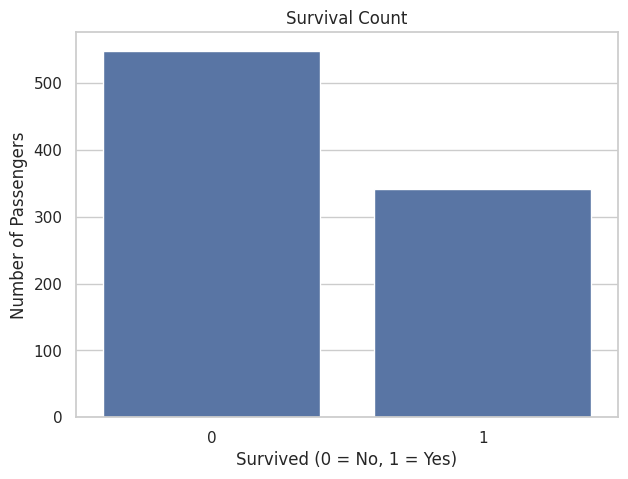

In [13]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="survived")

plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

**Survival by passenger class**

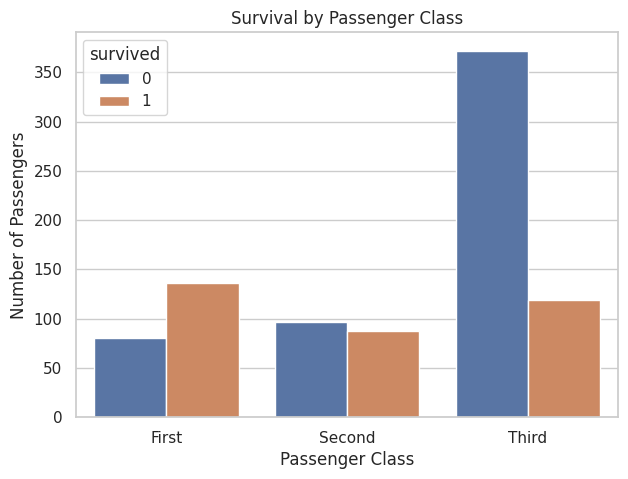

In [14]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="class", hue="survived")

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

This helps investigate the relationship between passenger class and survival.

  Age distribution

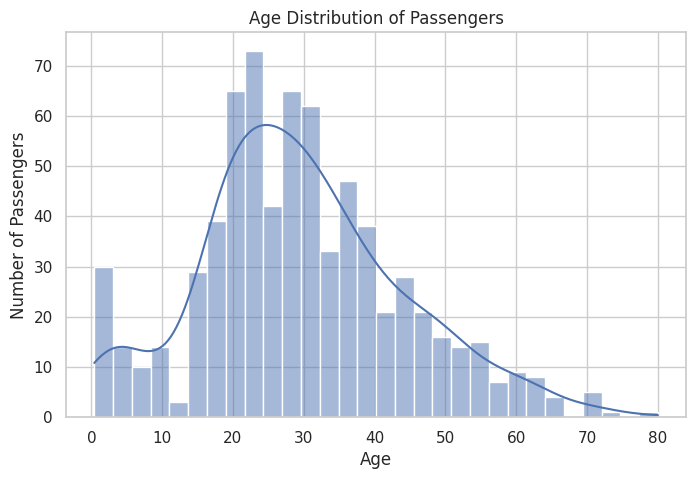

In [15]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="age", bins=30, kde=True)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

**Detect possible outliers**

Now we address the anomalies requirement.

Create a boxplot for age:

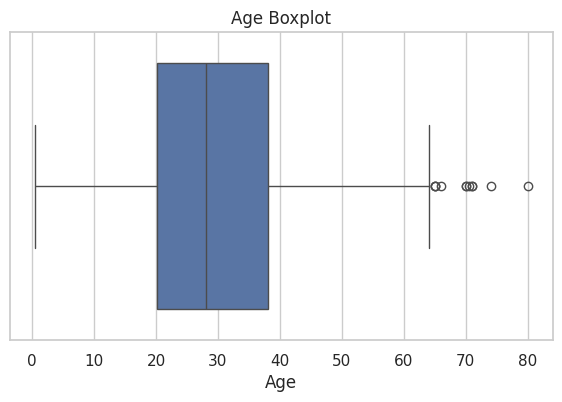

In [16]:
plt.figure(figsize=(7, 4))

sns.boxplot(x=df["age"])

plt.title("Age Boxplot")
plt.xlabel("Age")

plt.show()

The boxplots help identify unusually high or low values

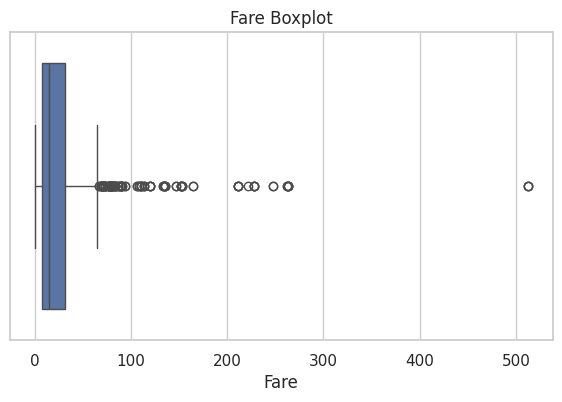

In [17]:
plt.figure(figsize=(7, 4))

sns.boxplot(x=df["fare"])

plt.title("Fare Boxplot")
plt.xlabel("Fare")

plt.show()

**Correlation analysis**

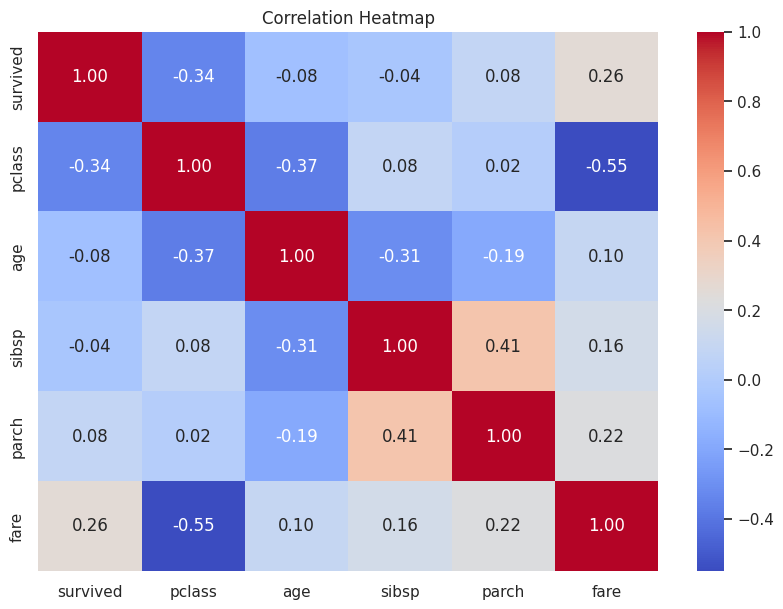

In [18]:
plt.figure(figsize=(10, 7))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

This helps us understand relationships between numerical variables.

**Test some observations statistically**

For example, calculate survival rates by gender:

In [19]:
gender_survival = df.groupby("sex")["survived"].mean() * 100

print("Survival rate by gender:")
print(gender_survival)

Survival rate by gender:
sex
female    74.203822
male      18.890815
Name: survived, dtype: float64


In [20]:
class_survival = df.groupby("class")["survived"].mean() * 100

print("Survival rate by passenger class:")
print(class_survival)

Survival rate by passenger class:
class
First     62.962963
Second    47.282609
Third     24.236253
Name: survived, dtype: float64


/tmp/ipykernel_1389/3052306604.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  class_survival = df.groupby("class")["survived"].mean() * 100


This gives numerical evidence to support what we see in the charts.

## Key Findings

* The dataset contains information about Titanic passengers and their characteristics.
* Survival outcomes were not evenly distributed among all passengers.
* Survival patterns differed across passenger genders.
* Passenger class showed noticeable differences in survival rates.
* Passenger ages covered a wide range, with some missing age values.
* Passenger fares showed a wide distribution and some unusually high values.
* The correlation analysis helped identify relationships between numerical variables.
* Missing values were identified in some columns and should be considered before further analysis.
* Boxplots were useful for detecting potential outliers and unusual observations.

## Data Quality Issues

The analysis identified several issues that should be considered:

* Missing values are present in some variables.
* Some numerical variables contain extreme values.
* Different columns use different data types.
* Missing values and outliers may affect statistical analysis if they are not handled appropriately.

## Conclusion

Exploratory Data Analysis provided a clear understanding of the Titanic dataset before further analysis. By examining the structure, descriptive statistics, missing values, distributions, relationships, and potential outliers, important patterns and data quality issues could be identified.

The combination of statistical analysis and visualization makes the dataset easier to understand and provides a foundation for further data analysis and machine learning tasks.
